# Student Performance Data Analysis

This notebook presents an in-depth analysis of the `student-mat.csv` dataset, which contains demographic, social, and school-related data for secondary school students in a mathematics course. The analysis focuses on data cleaning, exploring key variables, answering specific performance-related questions, and visualizing relationships.

## 1. Load Dataset

We load the dataset using the pandas library. Since the CSV utilizes a semicolon separator, we specify `sep=';'` in the read function.

In [1]:
import pandas as pd
df = pd.read_csv('student-mat.csv', sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


## 2. Explore & Clean Data

We explore the shape and data types of the dataset, check for missing values using `.isnull()`, and remove any duplicate entries.

### Checking for Missing Values

In [2]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0


### Removing Duplicates

In [3]:
initial_shape = df.shape
df = df.drop_duplicates()
final_shape = df.shape
print(f"Original shape: {initial_shape}")
print(f"Shape after removing duplicates: {final_shape}")

Original shape: (395, 33)
Shape after removing duplicates: (395, 33)


### Inspecting Data Types

In [4]:
df.dtypes

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64


## 3. Analysis Questions

We address specific analytical questions to extract insights about student performance and study habits.

### Question A: What is the average final grade (G3)?

In [5]:
average_g3 = df['G3'].mean()
print(f"Average Final Grade (G3): {average_g3:.2f}")

Average Final Grade (G3): 10.42


### Question B: How many students scored above 15 in final grades?

In [6]:
high_scorers = (df['G3'] > 15).sum()
print(f"Number of students scoring above 15: {high_scorers}")

Number of students scoring above 15: 40


### Question C: Is study time correlated with academic performance?

In [7]:
correlation = df['studytime'].corr(df['G3'])
print(f"Correlation coefficient between study time and final grade (G3): {correlation:.4f}")

Correlation coefficient between study time and final grade (G3): 0.0978


### Question D: Which gender performs better on average?

In [8]:
gender_performance = df.groupby('sex')['G3'].mean()
print("Average G3 Score by Gender:")
print(gender_performance)

Average G3 Score by Gender:
sex
F     9.966346
M    10.914439


## 4. Visualizations

We create beautiful, custom-designed charts to visually communicate the relationships and trends identified in the dataset.

### Visualization 1: Histogram of Grades (G3)

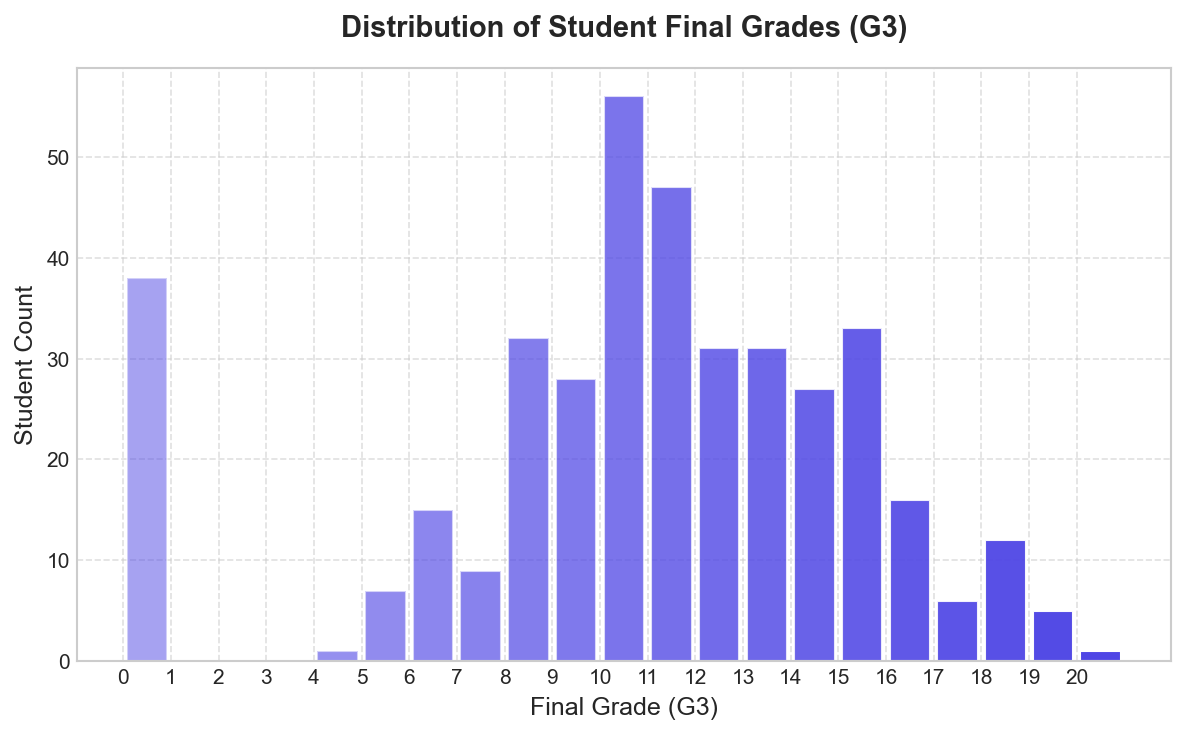

In [9]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 5))
counts, bins, patches = ax.hist(df['G3'], bins=range(0, 22), color='#4F46E5', edgecolor='#FFFFFF', rwidth=0.85)
for patch, left in zip(patches, bins[:-1]):
    alpha = 0.5 + 0.5 * (left / 20.0)
    patch.set_alpha(alpha)
ax.set_title('Distribution of Student Final Grades (G3)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Final Grade (G3)', fontsize=12)
ax.set_ylabel('Student Count', fontsize=12)
ax.set_xticks(range(0, 21))
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Visualization 2: Scatterplot of Study Time vs Final Grades

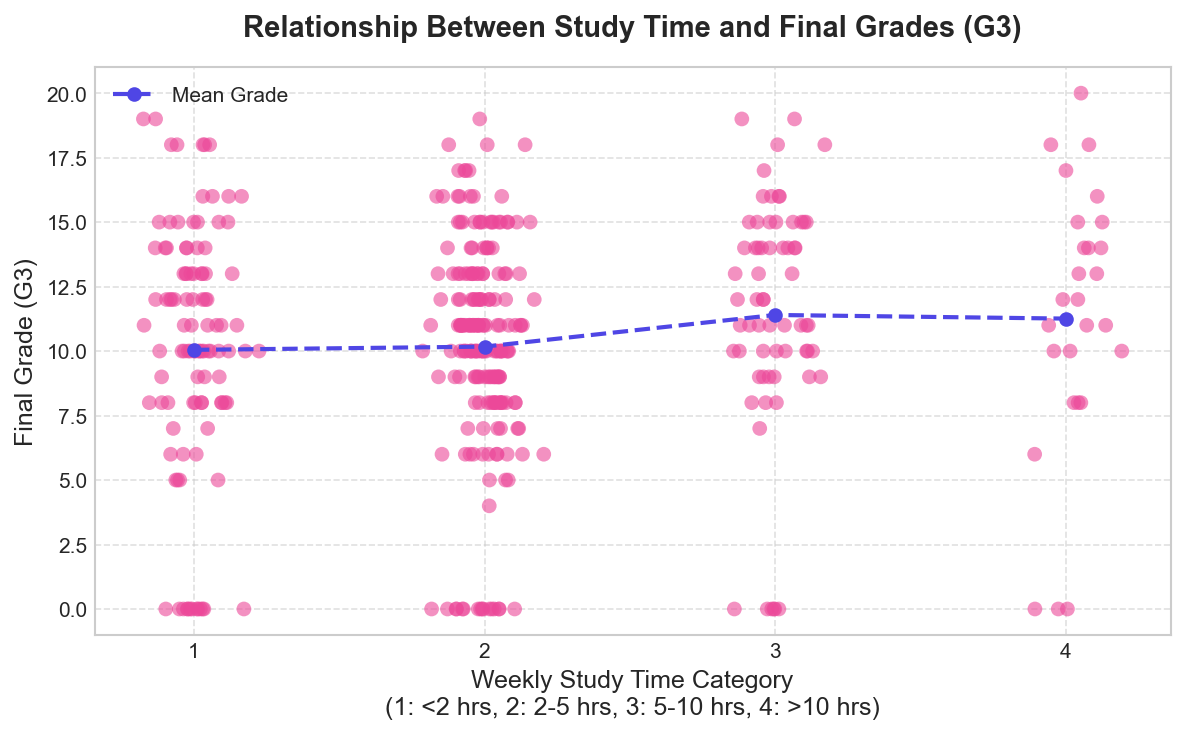

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
jitter = np.random.normal(0, 0.08, size=len(df))
ax.scatter(df['studytime'] + jitter, df['G3'], color='#EC4899', alpha=0.6, edgecolors='none', s=50)
x_vals = [1, 2, 3, 4]
y_vals = [df[df['studytime'] == x]['G3'].mean() for x in x_vals]
ax.plot(x_vals, y_vals, color='#4F46E5', linestyle='--', marker='o', linewidth=2, label='Mean Grade')
ax.set_title('Relationship Between Study Time and Final Grades (G3)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Weekly Study Time Category\n(1: <2 hrs, 2: 2-5 hrs, 3: 5-10 hrs, 4: >10 hrs)', fontsize=12)
ax.set_ylabel('Final Grade (G3)', fontsize=12)
ax.set_xticks([1, 2, 3, 4])
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()

### Visualization 3: Bar Chart of Male vs Female Average Score

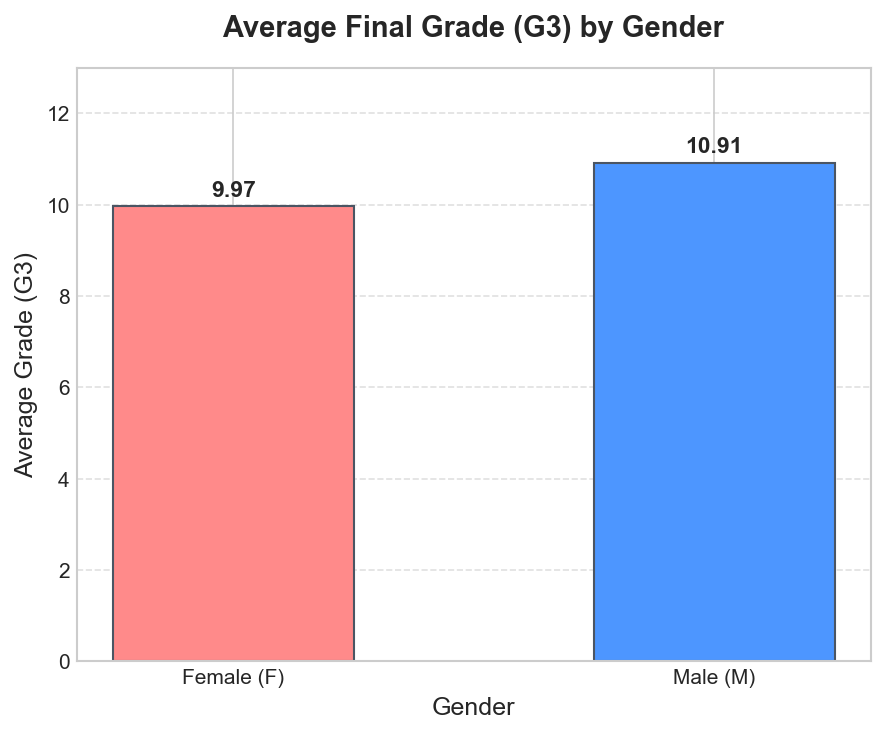

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
gender_means = df.groupby('sex')['G3'].mean()
colors = ['#FF8A8A', '#4D96FF']
bars = ax.bar(gender_means.index, gender_means.values, color=colors, width=0.5, edgecolor='#4B5563', linewidth=1)
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Average Final Grade (G3) by Gender', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Average Grade (G3)', fontsize=12)
ax.set_ylim(0, 13)
ax.set_xticks(range(len(gender_means.index)))
ax.set_xticklabels(['Female (F)', 'Male (M)'])
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Summary of Key Insights

- **Dataset Completeness:** The dataset consists of 395 students with 33 attributes. There are no missing values, and no duplicate records were identified, meaning the dataset was clean from the start.
- **Overall Final Grade:** The average student scored 10.42 out of 20, representing a standard passing mark.
- **High Performers:** Only 40 students (10.1% of the cohort) scored higher than 15, reflecting a strict grading scale or lower overall cohort scores.
- **Study Time Impact:** Weekly study hours correlate very weakly with the final grade (r = 0.0978). While more study is slightly positive for grades, it does not strongly predict a higher score on its own, suggesting that study quality, initial aptitude, and external factors might be highly influential.
- **Gender Disparities:** Male students achieved a slightly higher average score (10.91) than female students (9.97) in this mathematics course. Further investigations are needed to understand if this gap persists across other subjects.